# Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# import utils from parent directory
import sys
from pathlib import Path
parent_dir = str(Path().resolve().parents[0])
sys.path.insert(0, parent_dir)

In [3]:
import nltk

In [4]:
import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA
import utils.NLP as NLP

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dgaillot\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [6]:
import warnings
warnings.filterwarnings('ignore')


%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn'

In [7]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [8]:
# load csv

df = pd.read_csv('data/flipkart_com-ecommerce_sample_1050.csv')

# Contraintes

Afin d’extraire les features texte, il sera nécessaire de mettre en œuvre : 

- deux approches de type “bag-of-words”, comptage simple de mots et Tf-idf ;
- une approche de type word/sentence embedding classique avec Word2Vec (ou Glove ou FastText) ;
- une approche de type word/sentence embedding avec BERT ;
- une approche de type word/sentence embedding avec USE (Universal Sentence Encoder). 

En pièce jointe, tu trouveras un exemple de mise en œuvre de ces approches d’extraction de features texte sur un autre dataset. Je t’invite à l’utiliser comme point de départ, cela va te faire gagner beaucoup de temps !

Afin d’extraire les features image, il sera nécessaire de mettre en œuvre :

- un algorithme de type SIFT / ORB / SURF
- un algorithme de type CNN Transfer Learning.

# Explore & Select Features

In [9]:
df

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-multicolor-abstract-eyelet-door-curtain/p/itmeg7bkzdgthcts?pid=CRNEG7BKMFFYHQ8Z,Elegance Polyester Multicolor Abstract Eyelet Door Curtain,"[""Home Furnishing >> Curtains & Accessories >> Curtains >> Elegance Polyester Multicolor Abstract Eyelet Do...""]",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,"Key Features of Elegance Polyester Multicolor Abstract Eyelet Door Curtain Floral Curtain,Elegance Polyester Multicolor Abstract Eyelet Door Curtain (213 cm in Height, Pack of 2) Price: Rs. 899 This curtain enhances the look of the interiors.This curtain is made from 100% high quality polyester fabric.It features an eyelet style stitch with Metal Ring.It makes the room environment romantic and loving.This curtain is ant- wrinkle and anti shrinkage and have elegant apparance.Give your home a bright and modernistic appeal with these designs. The surreal attention is sure to steal hearts. These contemporary eyelet and valance curtains slide smoothly so when you draw them apart first thing in the morning to welcome the bright sun rays you want to wish good morning to the whole world and when you draw them close in the evening, you create the most special moments of joyous beauty given by the soothing prints. Bring home the elegant curtain that softly filters light in your room so that you get the right amount of sunlight.,Specifications of Elegance Polyester Multicolor Abstract Eyelet Door Curtain (213 cm in Height, Pack of 2) General Brand Elegance Designed For Door Type Eyelet Model Name Abstract Polyester Door Curtain Set Of 2 Model ID Duster25 Color Multicolor Dimensions Length 213 cm In the Box Number of Contents in Sales Package Pack of 2 Sales Package 2 Curtains Body & Design Material Polyester",No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""value""=>""Elegance""}, {""key""=>""Designed For"", ""value""=>""Door""}, {""key""=>""Type"", ""value""=>""Eyelet""}, {""key""=>""Model Name"", ""value""=>""Abstract Polyester Door Curtain Set Of 2""}, {""key""=>""Model ID"", ""value""=>""Duster25""}, {""key""=>""Color"", ""value""=>""Multicolor""}, {""key""=>""Length"", ""value""=>""213 cm""}, {""key""=>""Number of Contents in Sales Package"", ""value""=>""Pack of 2""}, {""key""=>""Sales Package"", ""value""=>""2 Curtains""}, {""key""=>""Material"", ""value""=>""Polyester""}]}"
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-towel/p/itmegfzhxbyucwgn?pid=BTWEGFZHGBXPHZUH,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath Towels >> Sathiyas Baby Bath Towels >> Sathiyas Cotton Bath Towel (3 Bath Towel, Red, Y...""]",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,"Specifications of Sathiyas Cotton Bath Towel (3 Bath Towel, Red, Yellow, Blue) Bath Towel Features Machine Washable Yes Material Cotton Design Self Design General Brand Sathiyas Type Bath Towel GSM 500 Model Name Sathiyas cotton bath towel Ideal For Men, Women, Boys, Girls Model ID asvtwl322 Color Red, Yellow, Blue Size Mediam Dimensions Length 30 inch Width 60 inch In the Box Number of Contents in Sales Package 3 Sales Package 3 Bath Towel",No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Washable"", ""value""=>""Yes""}, {""key""=>""Material"", ""value""=>""Cotton""}, {""key""=>""Design"", ""value""=>""Self Design""}, {""key""=>""Brand"", ""value""=>""Sathiyas""}, {""key""=>""Type"", ""value""=>""Bath Towel""}, {""key""=>""GSM"", ""value""=>""500""}, {""key""=>""Model Name"", ""value""=>""Sathiyas cotton bath towel""}, {""key""=>""Ideal For"",

In [10]:
df.columns

Index(['uniq_id', 'crawl_timestamp', 'product_url', 'product_name',
       'product_category_tree', 'pid', 'retail_price', 'discounted_price',
       'image', 'is_FK_Advantage_product', 'description', 'product_rating',
       'overall_rating', 'brand', 'product_specifications'],
      dtype='object')

In [11]:
# timestamps : data casting
df["crawl_timestamp"] = pd.to_datetime(df["crawl_timestamp"])

In [12]:
df.dtypes

uniq_id                                 object
crawl_timestamp            datetime64[ns, UTC]
product_url                             object
product_name                            object
product_category_tree                   object
pid                                     object
retail_price                           float64
discounted_price                       float64
image                                   object
is_FK_Advantage_product                   bool
description                             object
product_rating                          object
overall_rating                          object
brand                                   object
product_specifications                  object
dtype: object

In [13]:
df.describe()

,retail_price,discounted_price
count,1049.000000,1049.000000
mean,2186.197331,1584.527169
std,7639.229411,7475.099680
min,35.000000,35.000000
25%,555.000000,340.000000
50%,999.000000,600.000000
75%,1999.000000,1199.000000
max,201000.000000,201000.000000


In [14]:
dict_info = {"dataset": []
        ,"columns": []
        ,"total_rows": []
        ,"total_cols": []
        ,"total_duplicates": []
        ,"total_null": []
        ,"null_cols": []
}


dict_info["dataset"].append('flipkart') 
dict_info["columns"].append([', '.join([col for col, null in df.isnull().sum().items() ])])
dict_info["total_rows"].append(df.shape[0])
dict_info["total_cols"].append(df.shape[1])
dict_info["total_duplicates"].append(len(df[df.duplicated()]))
dict_info["total_null"].append(df.isnull().sum().sum())
dict_info["null_cols"].append([', '.join([col for col, null in df.isnull().sum().items() if null > 0])])
    
dict_info_df = pd.DataFrame.from_dict(dict_info)
dict_info_df.style.background_gradient(cmap='YlGnBu')

,dataset,columns,total_rows,total_cols,total_duplicates,total_null,null_cols
0,flipkart,"['uniq_id, crawl_timestamp, product_url, product_name, product_category_tree, pid, retail_price, discounted_price, image, is_FK_Advantage_product, description, product_rating, overall_rating, brand, product_specifications']",1050,15,0,341,"['retail_price, discounted_price, brand, product_specifications']"


In [15]:
dict_info = {"dataset": []
        ,"columns": []
        ,"total_rows": []
        ,"total_duplicates": []
        ,"total_null": []
}

for col in df.columns:
    dict_info["dataset"].append('flipkart') 
    dict_info["columns"].append(col)
    dict_info["total_rows"].append(df[col].shape[0])
    dict_info["total_duplicates"].append(len(df[col][df[col].duplicated()]))
    dict_info["total_null"].append(df[col].isnull().sum().sum())
    
dict_info_df = pd.DataFrame.from_dict(dict_info)
dict_info_df.style.background_gradient(cmap='YlGnBu')

,dataset,columns,total_rows,total_duplicates,total_null
0,flipkart,uniq_id,1050,0,0
1,flipkart,crawl_timestamp,1050,901,0
2,flipkart,product_url,1050,0,0
3,flipkart,product_name,1050,0,0
4,flipkart,product_category_tree,1050,408,0
5,flipkart,pid,1050,0,0
6,flipkart,retail_price,1050,695,1
7,flipkart,discounted_price,1050,625,1
8,flipkart,image,1050,0,0
9,flipkart,is_FK_Advantage_product,1050,1048,0


In [16]:
for col in df.columns:
    print(col)

uniq_id
crawl_timestamp
product_url
product_name
product_category_tree
pid
retail_price
discounted_price
image
is_FK_Advantage_product
description
product_rating
overall_rating
brand
product_specifications


In [17]:
df['uniq_id'].shape[0]

1050

In [18]:
#MVA.global_fill_info(df)
MVA.global_fill_info(df)

DataFrame has 1050 rows and 15 columns.

Global filling rate of the DataFrame: 97.83%
Missing values in the DataFrame: 341 (2.17%)

Number of rows with missing values: 340 (32.38%)
Number of columns with missing values: 4 (26.67%)


In [19]:
df.isna().sum()

uniq_id                      0
crawl_timestamp              0
product_url                  0
product_name                 0
product_category_tree        0
pid                          0
retail_price                 1
discounted_price             1
image                        0
is_FK_Advantage_product      0
description                  0
product_rating               0
overall_rating               0
brand                      338
product_specifications       1
dtype: int64

In [20]:
df.nunique()

uniq_id                    1050
crawl_timestamp             149
product_url                1050
product_name               1050
product_category_tree       642
pid                        1050
retail_price                354
discounted_price            424
image                      1050
is_FK_Advantage_product       2
description                1050
product_rating               27
overall_rating               27
brand                       490
product_specifications      984
dtype: int64

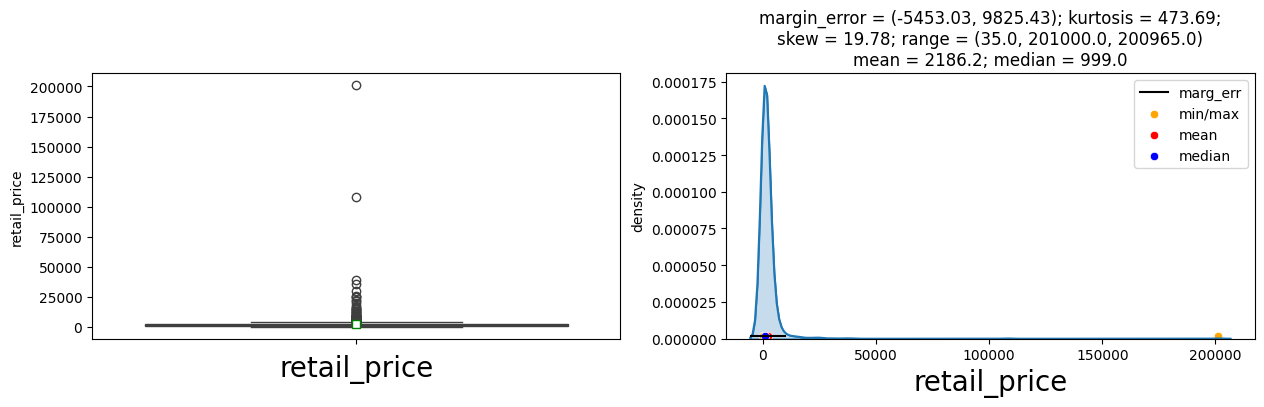

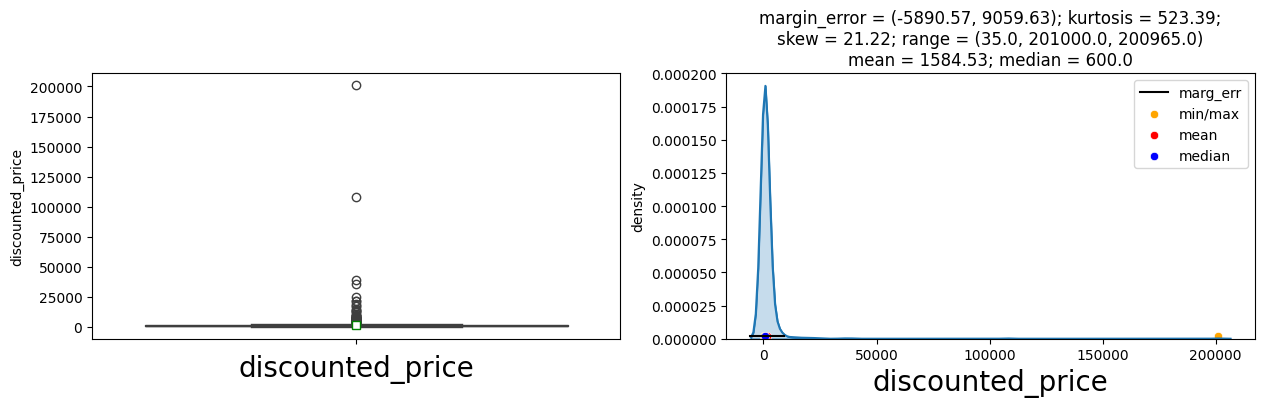

In [21]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
UVA.num_plus(df, num_cols)

## Feature reduction

In [22]:
cols_to_keep =['uniq_id',
            'product_name',
            'product_category_tree',
            'image',
            'description',
            'brand'
        ]

In [23]:
df = df[cols_to_keep]

In [24]:
df.head(5).T

,0,1,2,3,4
uniq_id,55b85ea15a1536d46b7190ad6fff8ce7,7b72c92c2f6c40268628ec5f14c6d590,64d5d4a258243731dc7bbb1eef49ad74,d4684dcdc759dd9cdf41504698d737d8,6325b6870c54cd47be6ebfbffa620ec7
product_name,Elegance Polyester Multicolor Abstract Eyelet Door Curtain,Sathiyas Cotton Bath Towel,Eurospa Cotton Terry Face Towel Set,SANTOSH ROYAL FASHION Cotton Printed King sized Double Bedsheet,Jaipur Print Cotton Floral King sized Double Bedsheet
product_category_tree,"[""Home Furnishing >> Curtains & Accessories >> Curtains >> Elegance Polyester Multicolor Abstract Eyelet Do...""]","[""Baby Care >> Baby Bath & Skin >> Baby Bath Towels >> Sathiyas Baby Bath Towels >> Sathiyas Cotton Bath Towel (3 Bath Towel, Red, Y...""]","[""Baby Care >> Baby Bath & Skin >> Baby Bath Towels >> Eurospa Baby Bath Towels >> Eurospa Cotton Terry Face Towel Set (20 PIECE FA...""]","[""Home Furnishing >> Bed Linen >> Bedsheets >> SANTOSH ROYAL FASHION Bedsheets >> SANTOSH ROYAL FASHION Cotton Printed King sized ...""]","[""Home Furnishing >> Bed Linen >> Bedsheets >> Jaipur Print Bedsheets >> Jaipur Print Cotton Floral King sized Double Bed...""]"
image,55b85ea15a1536d46b7190ad6fff8ce7.jpg,7b72c92c2f6c40268628ec5f14c6d590.jpg,64d5d4a258243731dc7bbb1eef49ad74.jpg,d4684dcdc759dd9cdf41504698d737d8.jpg,6325b6870c54cd47be6ebfbffa620ec7.jpg
description,"Key Features of Elegance Polyester Multicolor Abstract Eyelet Door Curtain Floral Curtain,Elegance Polyester Multicolor Abstract Eyelet Door Curtain (213 cm in Height, Pack of 2) Price: Rs. 899 This curtain enhances the look of the interiors.This curtain is made from 100% high quality polyester fabric.It features an eyelet style stitch with Metal Ring.It makes the room environment romantic and loving.This curtain is ant- wrinkle and anti shrinkage and have elegant apparance.Give your home a bright and modernistic appeal with these designs. The surreal attention is sure to steal hearts. These contemporary eyelet and valance curtains slide smoothly so when you draw them apart first thing in the morning to welcome the bright sun rays you want to wish good morning to the whole world and when you draw them close in the evening, you create the most special moments of joyous beauty given by the soothing prints. Bring home the elegant curtain that softly filters light in your room so that you get the right amount of sunlight.,Specifications of Elegance Polyester Multicolor Abstract Eyelet Door Curtain (213 cm in Height, Pack of 2) General Brand Elegance Designed For Door Type Eyelet Model Name Abstract Polyester Door Curtain Set Of 2 Model ID Duster25 Color Multicolor Dimensions Length 213 cm In the Box Number of Contents in Sales Package Pack of 2 Sales Package 2 Curtains Body & Design Material Polyester","Specifications of Sathiyas Cotton Bath Towel (3 Bath Towel, Red, Yellow, Blue) Bath Towel Features Machine Washable Yes Material Cotton Design Self Design General Brand Sathiyas Type Bath Towel GSM 500 Model Name Sathiyas cotton bath towel Ideal For Men, Women, Boys, Girls Model ID asvtwl322 Color Red, Yellow, Blue Size Mediam Dimensions Length 30 inch Width 60 inch In the Box Number of Contents in Sales Package 3 Sales Package 3 Bath Towel","Key Features of Eurospa Cotton Terry Face Towel Set Size: small Height: 9 inch GSM: 360,Eurospa Cotton Terry Face Towel Set (20 PIECE FACE TOWEL SET, Assorted) Price: Rs. 299 Eurospa brings to you an exclusively designed, 100% soft cotton towels of export quality. All our products have soft texture that takes care of your skin and gives you that enriched feeling you deserve. Eurospa has been exporting its bath towels to lot of renowned brands for last 10 years and is famous for its fine prints, absorbency, softness and durability. NOTE: Our product is 100% cotton, so it is susceptible to shrinkage. Product color may vary from the picture. Size may vary by ±3% WASH CARE: Wash in cold Water, Do not Iron, Do not Bleach, Flat dry, Wash before first use. SIZE- FACE TOWEL - 23 cms X 23 cms.,

In [25]:
df.isna().sum()

uniq_id                    0
product_name               0
product_category_tree      0
image                      0
description                0
brand                    338
dtype: int64

## Categories

### Pick first categories

In [26]:
df['product_category_tree'][0]

'["Home Furnishing >> Curtains & Accessories >> Curtains >> Elegance Polyester Multicolor Abstract Eyelet Do..."]'

In [27]:
df['description'][0]

'Key Features of Elegance Polyester Multicolor Abstract Eyelet Door Curtain Floral Curtain,Elegance Polyester Multicolor Abstract Eyelet Door Curtain (213 cm in Height, Pack of 2) Price: Rs. 899 This curtain enhances the look of the interiors.This curtain is made from 100% high quality polyester fabric.It features an eyelet style stitch with Metal Ring.It makes the room environment romantic and loving.This curtain is ant- wrinkle and anti shrinkage and have elegant apparance.Give your home a bright and modernistic appeal with these designs. The surreal attention is sure to steal hearts. These contemporary eyelet and valance curtains slide smoothly so when you draw them apart first thing in the morning to welcome the bright sun rays you want to wish good morning to the whole world and when you draw them close in the evening, you create the most special moments of joyous beauty given by the soothing prints. Bring home the elegant curtain that softly filters light in your room so that you

In [28]:
df['product_category_tree']

0                                ["Home Furnishing >> Curtains & Accessories >> Curtains >> Elegance Polyester Multicolor Abstract Eyelet Do..."]
1       ["Baby Care >> Baby Bath & Skin >> Baby Bath Towels >> Sathiyas Baby Bath Towels >> Sathiyas Cotton Bath Towel (3 Bath Towel, Red, Y..."]
2        ["Baby Care >> Baby Bath & Skin >> Baby Bath Towels >> Eurospa Baby Bath Towels >> Eurospa Cotton Terry Face Towel Set (20 PIECE FA..."]
3         ["Home Furnishing >> Bed Linen >> Bedsheets >> SANTOSH ROYAL FASHION Bedsheets >> SANTOSH ROYAL FASHION Cotton Printed King sized ..."]
4                  ["Home Furnishing >> Bed Linen >> Bedsheets >> Jaipur Print Bedsheets >> Jaipur Print Cotton Floral King sized Double Bed..."]
                                                                          ...                                                                    
1045                                                                      ["Baby Care >> Baby & Kids Gifts >> Stickers >> Or

In [29]:
df['description']

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [30]:
count_cat_separators = df['product_category_tree'].str.count(' >> ')

### Check Separators and missing values (brands)

<AxesSubplot:xlabel='product_category_tree', ylabel='Count'>

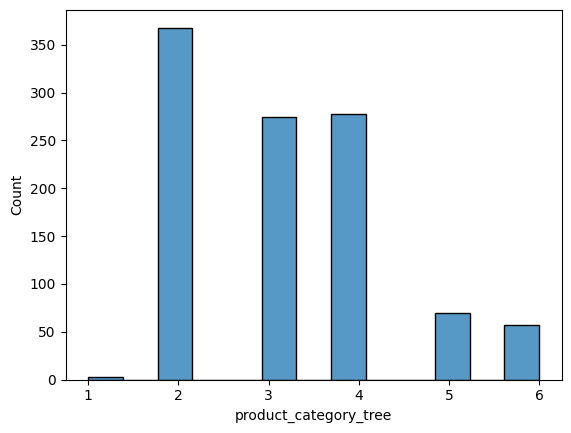

In [31]:
sns.histplot(count_cat_separators)

In [32]:
df['product_category_tree'][df['product_category_tree'].str.count(' >> ') == 1]

250    ["Home Decor & Festive Needs >> TRUE Home Decor & Festive Needs"]
873                                        ["Home Furnishing >> Living"]
875                                        ["Home Furnishing >> Living"]
Name: product_category_tree, dtype: object

In [33]:
df['product_category_tree'][df['product_category_tree'].str.count(' >> ') == 2]

5                                                ["Watches >> Wrist Watches >> Maserati Time Wrist Watches"]
6                                                      ["Watches >> Wrist Watches >> Camerii Wrist Watches"]
7                                                       ["Watches >> Wrist Watches >> T STAR Wrist Watches"]
8                                                       ["Watches >> Wrist Watches >> Alfajr Wrist Watches"]
9                                                    ["Watches >> Wrist Watches >> TAG Heuer Wrist Watches"]
10                                                     ["Watches >> Wrist Watches >> Calibro Wrist Watches"]
11                                                     ["Watches >> Wrist Watches >> Cartier Wrist Watches"]
12                                                  ["Watches >> Wrist Watches >> Lois Caron Wrist Watches"]
13                                                       ["Watches >> Wrist Watches >> Titan Wrist Watches"]
14                 

### Retrieve categories from 'product_category_tree 

In [34]:
def get_categories_from_series(series):
    
    # Function to get the 3 first cat
    def get_categories_from_cell(cell):
        product_category_tree = cell.strip('[]"')
        product_categories_list = product_category_tree.split(" >> ")
        
        categories = pd.Series()
        
        for i in range(min(3, len(product_categories_list))):
            categories["cat_{}".format(i+1)] = product_categories_list[i]
        
        return categories

    categories_df = series.apply(get_categories_from_cell).fillna("")
    return categories_df

In [35]:
df_cat = get_categories_from_series(df['product_category_tree'])

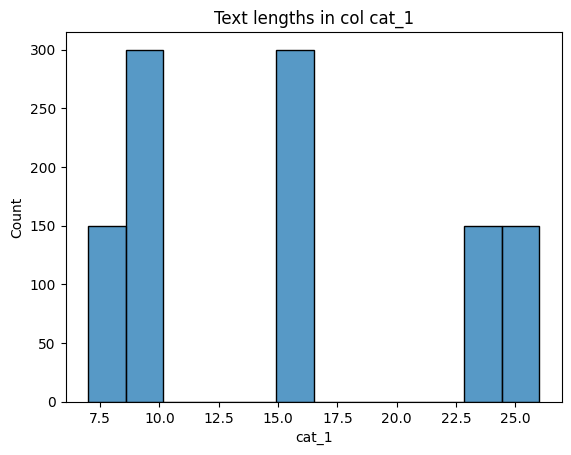

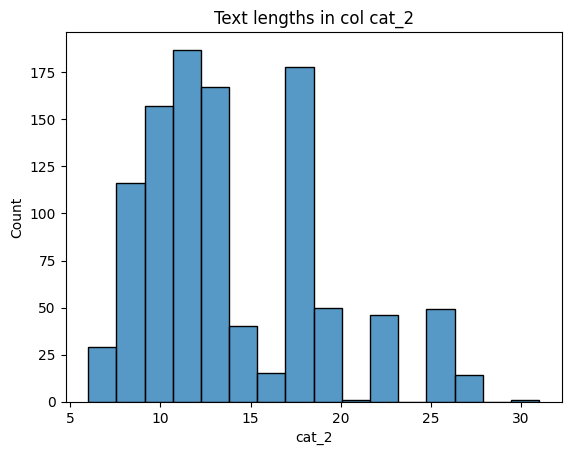

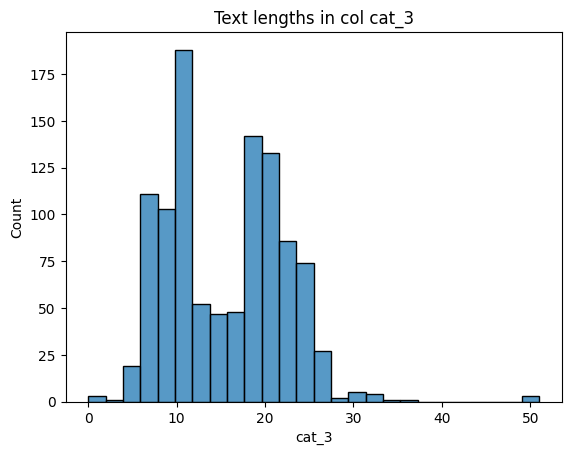

In [36]:
for col in df_cat.columns:
    str_len = df_cat[col].str.len()
    plt.figure(col)
    sns.histplot(str_len).set(title=f'Text lengths in col {col}')

In [37]:
df_cat.columns

Index(['cat_1', 'cat_2', 'cat_3'], dtype='object')

#### distribution of first category levels

In [38]:
df_cat.nunique()

cat_1      7
cat_2     62
cat_3    242
dtype: int64

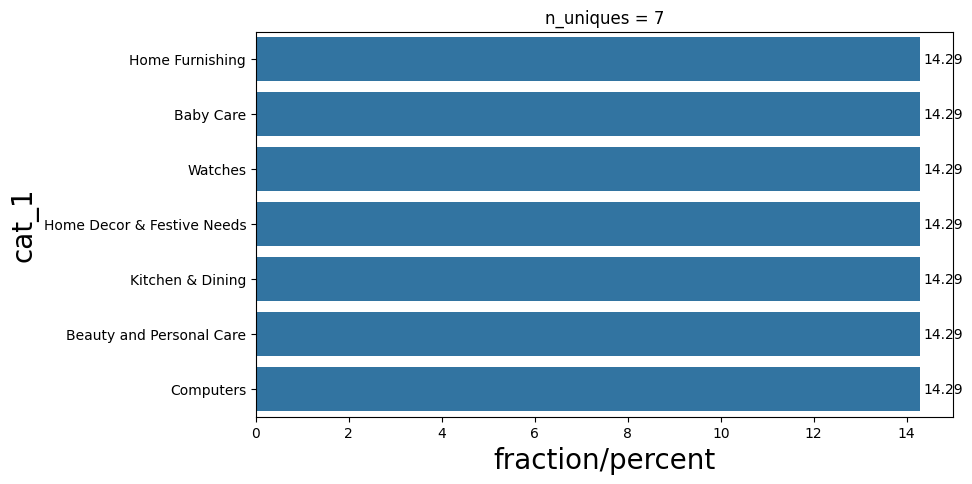

In [39]:
UVA.category(df_cat, ['cat_1'], 9, 5)

In [40]:
df = pd.concat([df, df_cat], axis=1)

In [41]:
df.head().T

,0,1,2,3,4
uniq_id,55b85ea15a1536d46b7190ad6fff8ce7,7b72c92c2f6c40268628ec5f14c6d590,64d5d4a258243731dc7bbb1eef49ad74,d4684dcdc759dd9cdf41504698d737d8,6325b6870c54cd47be6ebfbffa620ec7
product_name,Elegance Polyester Multicolor Abstract Eyelet Door Curtain,Sathiyas Cotton Bath Towel,Eurospa Cotton Terry Face Towel Set,SANTOSH ROYAL FASHION Cotton Printed King sized Double Bedsheet,Jaipur Print Cotton Floral King sized Double Bedsheet
product_category_tree,"[""Home Furnishing >> Curtains & Accessories >> Curtains >> Elegance Polyester Multicolor Abstract Eyelet Do...""]","[""Baby Care >> Baby Bath & Skin >> Baby Bath Towels >> Sathiyas Baby Bath Towels >> Sathiyas Cotton Bath Towel (3 Bath Towel, Red, Y...""]","[""Baby Care >> Baby Bath & Skin >> Baby Bath Towels >> Eurospa Baby Bath Towels >> Eurospa Cotton Terry Face Towel Set (20 PIECE FA...""]","[""Home Furnishing >> Bed Linen >> Bedsheets >> SANTOSH ROYAL FASHION Bedsheets >> SANTOSH ROYAL FASHION Cotton Printed King sized ...""]","[""Home Furnishing >> Bed Linen >> Bedsheets >> Jaipur Print Bedsheets >> Jaipur Print Cotton Floral King sized Double Bed...""]"
image,55b85ea15a1536d46b7190ad6fff8ce7.jpg,7b72c92c2f6c40268628ec5f14c6d590.jpg,64d5d4a258243731dc7bbb1eef49ad74.jpg,d4684dcdc759dd9cdf41504698d737d8.jpg,6325b6870c54cd47be6ebfbffa620ec7.jpg
description,"Key Features of Elegance Polyester Multicolor Abstract Eyelet Door Curtain Floral Curtain,Elegance Polyester Multicolor Abstract Eyelet Door Curtain (213 cm in Height, Pack of 2) Price: Rs. 899 This curtain enhances the look of the interiors.This curtain is made from 100% high quality polyester fabric.It features an eyelet style stitch with Metal Ring.It makes the room environment romantic and loving.This curtain is ant- wrinkle and anti shrinkage and have elegant apparance.Give your home a bright and modernistic appeal with these designs. The surreal attention is sure to steal hearts. These contemporary eyelet and valance curtains slide smoothly so when you draw them apart first thing in the morning to welcome the bright sun rays you want to wish good morning to the whole world and when you draw them close in the evening, you create the most special moments of joyous beauty given by the soothing prints. Bring home the elegant curtain that softly filters light in your room so that you get the right amount of sunlight.,Specifications of Elegance Polyester Multicolor Abstract Eyelet Door Curtain (213 cm in Height, Pack of 2) General Brand Elegance Designed For Door Type Eyelet Model Name Abstract Polyester Door Curtain Set Of 2 Model ID Duster25 Color Multicolor Dimensions Length 213 cm In the Box Number of Contents in Sales Package Pack of 2 Sales Package 2 Curtains Body & Design Material Polyester","Specifications of Sathiyas Cotton Bath Towel (3 Bath Towel, Red, Yellow, Blue) Bath Towel Features Machine Washable Yes Material Cotton Design Self Design General Brand Sathiyas Type Bath Towel GSM 500 Model Name Sathiyas cotton bath towel Ideal For Men, Women, Boys, Girls Model ID asvtwl322 Color Red, Yellow, Blue Size Mediam Dimensions Length 30 inch Width 60 inch In the Box Number of Contents in Sales Package 3 Sales Package 3 Bath Towel","Key Features of Eurospa Cotton Terry Face Towel Set Size: small Height: 9 inch GSM: 360,Eurospa Cotton Terry Face Towel Set (20 PIECE FACE TOWEL SET, Assorted) Price: Rs. 299 Eurospa brings to you an exclusively designed, 100% soft cotton towels of export quality. All our products have soft texture that takes care of your skin and gives you that enriched feeling you deserve. Eurospa has been exporting its bath towels to lot of renowned brands for last 10 years and is famous for its fine prints, absorbency, softness and durability. NOTE: Our product is 100% cotton, so it is susceptible to shrinkage. Product color may vary from the picture. Size may vary by ±3% WASH CARE: Wash in cold Water, Do not Iron, Do not Bleach, Flat dry, Wash before first use. SIZE- FACE TOWEL - 23 cms X 23 cms.,

### Check + fill erroneous/missing data (brands in categories)

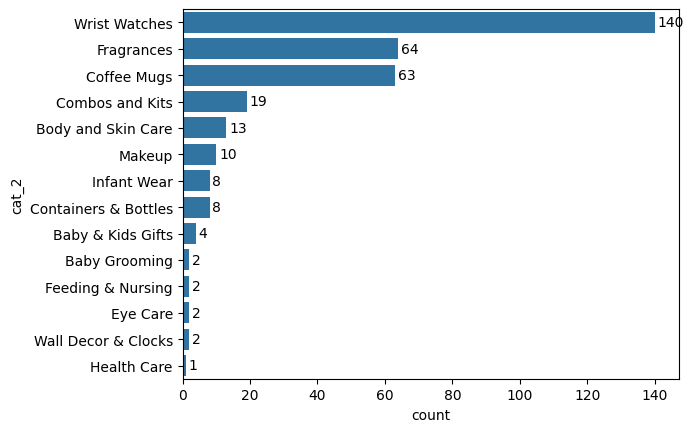

In [42]:
ax = sns.countplot(data = df[df['brand'].isna()]['cat_2']
                   ,order = df[df['brand'].isna()]['cat_2'].value_counts().index
                   )
for container in ax.containers:
    ax.bar_label(container, padding=2)

In [43]:
df['cat_2']

0       Curtains & Accessories
1             Baby Bath & Skin
2             Baby Bath & Skin
3                    Bed Linen
4                    Bed Linen
                 ...          
1045         Baby & Kids Gifts
1046         Baby & Kids Gifts
1047         Baby & Kids Gifts
1048         Baby & Kids Gifts
1049         Baby & Kids Gifts
Name: cat_2, Length: 1050, dtype: object

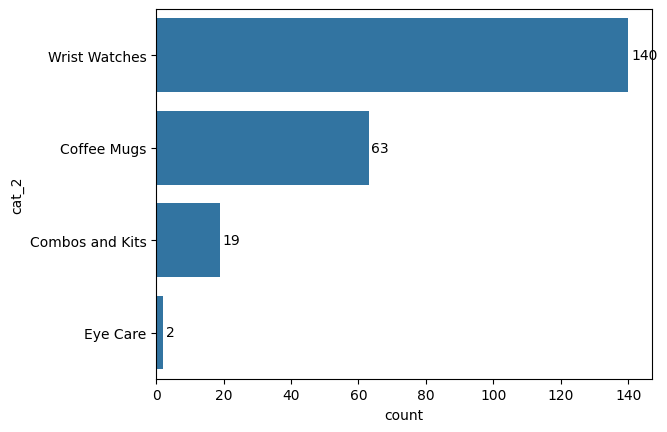

In [44]:
# identify second categories having a missing brand
mask = (df['brand'].isna()) & (df['product_category_tree'].str.count(' >> ') == 2)

ax = sns.countplot(data = df[mask]['cat_2']
                   ,order = df[mask]['cat_2'].value_counts().index
                   )
for container in ax.containers:
    ax.bar_label(container, padding=2)

=> some categories are actualling missing brands misslabeled as lower categories

In [45]:
cat_second_to_third_duplicates = df[mask]['cat_2'].unique().tolist()
cat_second_to_third_duplicates

['Wrist Watches', 'Coffee Mugs', 'Combos and Kits', 'Eye Care']

In [46]:
display_cat = cat_second_to_third_duplicates[0]
display_cols = ['uniq_id', 'brand','cat_1', 'cat_2', 'cat_3']
df[(df['cat_2'] == display_cat) & (df['product_category_tree'].str.count(' >> ') == 2)][display_cols]

,uniq_id,brand,cat_1,cat_2,cat_3
5,893aa5ed55f7cff2eccea7758d7a86bd,NaN,Watches,Wrist Watches,Maserati Time Wrist Watches
6,f355cc1ccb08bd0d283ed979b7ee7515,NaN,Watches,Wrist Watches,Camerii Wrist Watches
7,dd0e3470a7e6ed76fd69c2da27721041,NaN,Watches,Wrist Watches,T STAR Wrist Watches
8,41384da51732c0b4df3de8f395714fbb,NaN,Watches,Wrist Watches,Alfajr Wrist Watches
9,710ed5f2393a4b9e8823aa0029f71f93,NaN,Watches,Wrist Watches,TAG Heuer Wrist Watches
10,920154acbe49d3202ed7d2ed2df1ea13,NaN,Watches,Wrist Watches,Calibro Wrist Watches
11,08452abdadb3db1e686b94a9c52fc7b6,NaN,Watches,Wrist Watches,Cartier Wrist Watches
12,1e8741b5ae27a513546c94b3f3312aee,NaN,Watches,Wrist Watches,Lois Caron Wrist Watches
13,189fa66a5fa6f08d2802a62ecf0be298,NaN,Watches,Wrist Watches,Titan Wrist Watches
14,bbb8cdc5406ff60ff06ff64630f2ca47,NaN,Watches,Wrist Watches,Srushti Art Jewelry Wrist Watches


In [47]:
def process_row(row):
    # retirer le texte de cat_2 de cat_3
    brand = row['cat_3'].replace(row['cat_2'], '')
    # mettre à jour les valeurs des colonnes brand et cat_3
    row['brand'] = brand.strip()
    row['cat_3'] = None
    # renvoyer la ligne mise à jour
    return row

In [48]:
df[mask] = df[mask].apply(process_row, axis=1)
df[mask][display_cols]

,uniq_id,brand,cat_1,cat_2,cat_3
5,893aa5ed55f7cff2eccea7758d7a86bd,Maserati Time,Watches,Wrist Watches,None
6,f355cc1ccb08bd0d283ed979b7ee7515,Camerii,Watches,Wrist Watches,None
7,dd0e3470a7e6ed76fd69c2da27721041,T STAR,Watches,Wrist Watches,None
8,41384da51732c0b4df3de8f395714fbb,Alfajr,Watches,Wrist Watches,None
9,710ed5f2393a4b9e8823aa0029f71f93,TAG Heuer,Watches,Wrist Watches,None
10,920154acbe49d3202ed7d2ed2df1ea13,Calibro,Watches,Wrist Watches,None
11,08452abdadb3db1e686b94a9c52fc7b6,Cartier,Watches,Wrist Watches,None
12,1e8741b5ae27a513546c94b3f3312aee,Lois Caron,Watches,Wrist Watches,None
13,189fa66a5fa6f08d2802a62ecf0be298,Titan,Watches,Wrist Watches,None
14,bbb8cdc5406ff60ff06ff64630f2ca47,Srushti Art Jewelry,Watches,Wrist Watches,None


In [49]:
# for cat in cat_second_to_third_duplicates:
#   print(f'{cat} column processing')
#   mask = (df['cat_2'] == cat) & (df['product_category_tree'].str.count(' >> ') == 2)
#  df[mask] = df[mask].apply(process_row, axis=1)

In [50]:
# check
df[df['cat_2'].isin(cat_second_to_third_duplicates)][display_cols]

,uniq_id,brand,cat_1,cat_2,cat_3
5,893aa5ed55f7cff2eccea7758d7a86bd,Maserati Time,Watches,Wrist Watches,None
6,f355cc1ccb08bd0d283ed979b7ee7515,Camerii,Watches,Wrist Watches,None
7,dd0e3470a7e6ed76fd69c2da27721041,T STAR,Watches,Wrist Watches,None
8,41384da51732c0b4df3de8f395714fbb,Alfajr,Watches,Wrist Watches,None
9,710ed5f2393a4b9e8823aa0029f71f93,TAG Heuer,Watches,Wrist Watches,None
10,920154acbe49d3202ed7d2ed2df1ea13,Calibro,Watches,Wrist Watches,None
11,08452abdadb3db1e686b94a9c52fc7b6,Cartier,Watches,Wrist Watches,None
12,1e8741b5ae27a513546c94b3f3312aee,Lois Caron,Watches,Wrist Watches,None
13,189fa66a5fa6f08d2802a62ecf0be298,Titan,Watches,Wrist Watches,None
14,bbb8cdc5406ff60ff06ff64630f2ca47,Srushti Art Jewelry,Watches,Wrist Watches,None


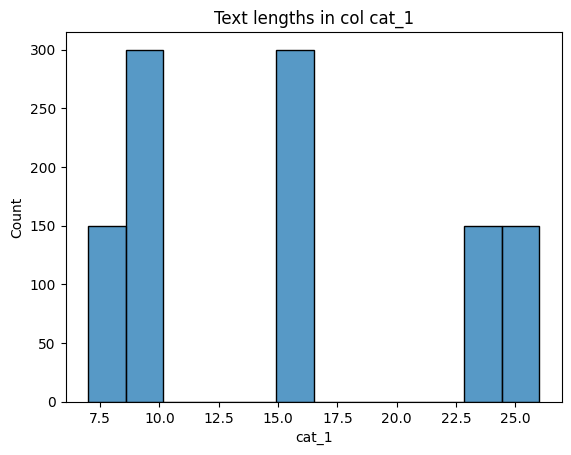

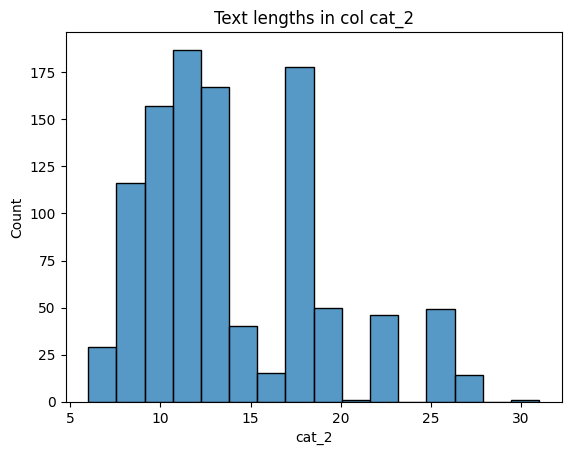

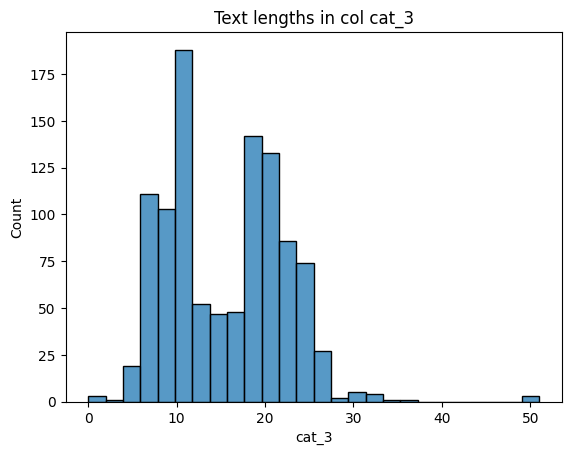

In [51]:
for col in df_cat.columns:
    str_len = df_cat[col].str.len()
    plt.figure(col)
    sns.histplot(str_len).set(title=f'Text lengths in col {col}')

In [52]:
df.columns

Index(['uniq_id', 'product_name', 'product_category_tree', 'image',
       'description', 'brand', 'cat_1', 'cat_2', 'cat_3'],
      dtype='object')

In [53]:
display_cols

['uniq_id', 'brand', 'cat_1', 'cat_2', 'cat_3']

In [54]:
mask = df['brand'].isna()
df[mask][['uniq_id', 'brand','product_category_tree', 'cat_1', 'cat_2', 'cat_3']]

,uniq_id,brand,product_category_tree,cat_1,cat_2,cat_3
56,24e85c590481a7cedfe66597f253f2b2,NaN,"[""Beauty and Personal Care >> Makeup >> Vanity Boxes >> Borse Vanity Boxes""]",Beauty and Personal Care,Makeup,Vanity Boxes
98,5749bae8ccead7997ebf370b6b081d07,NaN,"[""Beauty and Personal Care >> Makeup >> Vanity Boxes >> Kuber Industries Vanity Boxes""]",Beauty and Personal Care,Makeup,Vanity Boxes
99,059493eeb88ebb4cc08d1522f3f87c3f,NaN,"[""Beauty and Personal Care >> Makeup >> Vanity Boxes >> Thar Handloom Vanity Boxes""]",Beauty and Personal Care,Makeup,Vanity Boxes
100,9613f2f1e65fb1fc7e181e7f83c217da,NaN,"[""Beauty and Personal Care >> Makeup >> Vanity Boxes >> Goldencollections Vanity Boxes""]",Beauty and Personal Care,Makeup,Vanity Boxes
114,bc784846bd59a16832454416ac708003,NaN,"[""Baby Care >> Baby Grooming >> Baby Grooming Combos >> Lollipop Lane Baby Grooming Combos""]",Baby Care,Baby Grooming,Baby Grooming Combos
117,be09f5a3a88ac10ae14c791fc8ac0dae,NaN,"[""Baby Care >> Infant Wear >> Baby Boys' Clothes >> Bodysuits & Sleepsuits >> Bodysuits >> Anthill Bodysuits""]",Baby Care,Infant Wear,Baby Boys' Clothes
125,7241df1acae1fac892c692097ea3fb98,NaN,"[""Beauty and Personal Care >> Body and Skin Care >> Hand Care >> Manicure and Kits >> Sally Hansen Manicure and Kits""]",Beauty and Personal Care,Body and Skin Care,Hand Care
126,a85a7dbd31267a7b02eda3a4d484632d,NaN,"[""Beauty and Personal Care >> Body and Skin Care >> Hand Care >> Manicure and Kits >> Svayam Manicure and Kits""]",Beauty and Personal Care,Body and Skin Care,Hand Care
127,13de17e59a92f8bcaec8bf103bbff8c1,NaN,"[""Beauty and Personal Care >> Body and Skin Care >> Hand Care >> Manicure and Kits >> Go Bonjour Manicure and Kits""]",Beauty and Personal Care,Body and Skin Care,Hand Care
202,70578f48cc96bbb60d040e08025e521d,NaN,"[""Baby Care >> Infant Wear >> Baby Boys' Clothes >> Dungarees & Jumpsuits >> Jumpsuits >> Earth Conscious Jumpsuits""]",Baby Care,Infant Wear,Baby Boys' Clothes


In [55]:
df[mask]['product_category_tree']

56                                               ["Beauty and Personal Care >> Makeup >> Vanity Boxes >> Borse Vanity Boxes"]
98                                    ["Beauty and Personal Care >> Makeup >> Vanity Boxes >> Kuber Industries Vanity Boxes"]
99                                       ["Beauty and Personal Care >> Makeup >> Vanity Boxes >> Thar Handloom Vanity Boxes"]
100                                  ["Beauty and Personal Care >> Makeup >> Vanity Boxes >> Goldencollections Vanity Boxes"]
114                              ["Baby Care >> Baby Grooming >> Baby Grooming Combos >> Lollipop Lane Baby Grooming Combos"]
117            ["Baby Care >> Infant Wear >> Baby Boys' Clothes >> Bodysuits & Sleepsuits >> Bodysuits >> Anthill Bodysuits"]
125    ["Beauty and Personal Care >> Body and Skin Care >> Hand Care >> Manicure and Kits >> Sally Hansen Manicure and Kits"]
126          ["Beauty and Personal Care >> Body and Skin Care >> Hand Care >> Manicure and Kits >> Svayam Manicure and

In [56]:
def process_row_2(row):
    product_category_tree = row['product_category_tree'].strip('[]"')
    # récupérer le dernier élément séparé par ' >> ' dans product_category_tree
    last_element = product_category_tree.split(' >> ')[-1]
    second_last_element = product_category_tree.split(' >> ')[-2]
    # retirer le texte de second_last_element de last_element
    brand = last_element.replace(second_last_element, '').strip()
    # mettre à jour la valeur de la colonne brand
    row['brand'] = brand
    # renvoyer la ligne mise à jour
    return row

In [57]:
df[mask] = df[mask].apply(process_row_2, axis=1)

In [58]:
df[mask][['uniq_id', 'brand','product_category_tree', 'cat_1', 'cat_2', 'cat_3']]

,uniq_id,brand,product_category_tree,cat_1,cat_2,cat_3
56,24e85c590481a7cedfe66597f253f2b2,Borse,"[""Beauty and Personal Care >> Makeup >> Vanity Boxes >> Borse Vanity Boxes""]",Beauty and Personal Care,Makeup,Vanity Boxes
98,5749bae8ccead7997ebf370b6b081d07,Kuber Industries,"[""Beauty and Personal Care >> Makeup >> Vanity Boxes >> Kuber Industries Vanity Boxes""]",Beauty and Personal Care,Makeup,Vanity Boxes
99,059493eeb88ebb4cc08d1522f3f87c3f,Thar Handloom,"[""Beauty and Personal Care >> Makeup >> Vanity Boxes >> Thar Handloom Vanity Boxes""]",Beauty and Personal Care,Makeup,Vanity Boxes
100,9613f2f1e65fb1fc7e181e7f83c217da,Goldencollections,"[""Beauty and Personal Care >> Makeup >> Vanity Boxes >> Goldencollections Vanity Boxes""]",Beauty and Personal Care,Makeup,Vanity Boxes
114,bc784846bd59a16832454416ac708003,Lollipop Lane,"[""Baby Care >> Baby Grooming >> Baby Grooming Combos >> Lollipop Lane Baby Grooming Combos""]",Baby Care,Baby Grooming,Baby Grooming Combos
117,be09f5a3a88ac10ae14c791fc8ac0dae,Anthill,"[""Baby Care >> Infant Wear >> Baby Boys' Clothes >> Bodysuits & Sleepsuits >> Bodysuits >> Anthill Bodysuits""]",Baby Care,Infant Wear,Baby Boys' Clothes
125,7241df1acae1fac892c692097ea3fb98,Sally Hansen,"[""Beauty and Personal Care >> Body and Skin Care >> Hand Care >> Manicure and Kits >> Sally Hansen Manicure and Kits""]",Beauty and Personal Care,Body and Skin Care,Hand Care
126,a85a7dbd31267a7b02eda3a4d484632d,Svayam,"[""Beauty and Personal Care >> Body and Skin Care >> Hand Care >> Manicure and Kits >> Svayam Manicure and Kits""]",Beauty and Personal Care,Body and Skin Care,Hand Care
127,13de17e59a92f8bcaec8bf103bbff8c1,Go Bonjour,"[""Beauty and Personal Care >> Body and Skin Care >> Hand Care >> Manicure and Kits >> Go Bonjour Manicure and Kits""]",Beauty and Personal Care,Body and Skin Care,Hand Care
202,70578f48cc96bbb60d040e08025e521d,Earth Conscious,"[""Baby Care >> Infant Wear >> Baby Boys' Clothes >> Dungarees & Jumpsuits >> Jumpsuits >> Earth Conscious Jumpsuits""]",Baby Care,Infant Wear,Baby Boys' Clothes


In [59]:
df.isna().sum()

uniq_id                    0
product_name               0
product_category_tree      0
image                      0
description                0
brand                      0
cat_1                      0
cat_2                      0
cat_3                    224
dtype: int64

In [60]:
df[df['cat_3'].isna()].T

,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,494,495,496,497,498,499,500,501,502,...,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,652,741,747,748,757,759,760,761,762,763,764,767,768,769,777,778,779,780,781,782,786,787,788,790,791,792,794,795,796,797,798,801,802,804,805,806,807,808,809,810,820,823,825,826
uniq_id,893aa5ed55f7cff2eccea7758d7a86bd,f355cc1ccb08bd0d283ed979b7ee7515,dd0e3470a7e6ed76fd69c2da27721041,41384da51732c0b4df3de8f395714fbb,710ed5f2393a4b9e8823aa0029f71f93,920154acbe49d3202ed7d2ed2df1ea13,08452abdadb3db1e686b94a9c52fc7b6,1e8741b5ae27a513546c94b3f3312aee,189fa66a5fa6f08d2802a62ecf0be298,bbb8cdc5406ff60ff06ff64630f2ca47,1120bc768623572513df956172ffefeb,5479bb7028827d60000720a2c135976a,733aa1e801a139fa8dc7be9f0eff5ee0,62c35de4df27437d3597963fac55a8b6,33d97d63c037078cd3f08033966d6a88,d7ca2b06b4f4d3b98c61c377b18a2d6b,f74476ba64365d97a5be7d375cbf4c7a,fda50982a672ef8835de5c1cc86f8bfc,4788f5466992da09024b8ffcc8a5cba4,653826cd53f1d9e2c086c0ac7846ef70,3c74db45cbfc14a78b8466dca494b3bb,4aa047f14885c74f155ce5f973e14dff,7c4fec2331da8d40f2cb146eb198cb57,b52073e7ed9c00c4108cae4eb0c49c1a,ee8d9ff65e0fe4278afce7c933d30941,788dc3a3da91c0f46a7c465e07f91dd4,29b1ca231e10d5269516b80bf9d0dffc,8b268c1e68f198ae2e934717d49f48e9,f1484a63c0dc79e96c98b2a250380ed8,f01ff0a82401117e9da22dd680fd2f36,de911421573d3e234450040374b55b38,614dbfa2f42c4684c0bb6152091113a6,5531b9f454e2d75cfe00c3f795e06de5,258444ac7bb7ad8026800efad5c3502b,fd369a1bb58ae02cd925dda7e9e1d00a,73f460cd6f3fd206902d7097a1816405,0d3e1dc0d38be59e9927e47f152e48aa,118b411bf265538461b084ce7abd55a8,06749cbff1487f470438823f6952cfd1,202fc276e672eb8c29891aa50aef0771,feefbdff924dd6b7cc266449c9a36d69,af1ac46194b5488048c459102a16a57e,a1fd886094826c3f25c6ffb380073974,3847353a4b8de1efc504d589aea74ffe,60efd61370e70267dc60b11ff2bf974c,63bc43c0000e71eb11bfafd2f46214a4,f8794f7a06b530782c66f7c0911bb437,8507eb0ef32c1c0db700f20aad6d9bcd,fc7abdf67b4d7dbf64dffbab7b37599c,1afa5f2c3c9b4b43def6dc2e695d2c87,73503fe89ea77420a598f4a1019e5b6d,ec590694e8bf85f75c9200cf418127aa,7956d9586de3e25ff586bca58be7195e,63f6ef8f3fda2c306b27cfbf5a005f1e,328b66226952d8733c0c48295fae1108,6efd5d260667b94f04edbbd18bb300b9,beaa6285a2b9c66db0e294767711ca3f,41fd5af61752be98b19b611a6ff9a0ef,219b24362655097cb41bf06a0be8ee79,b5d1b8ef70b1ce27726f7f6c2f373e56,69515ea06da8b2b1c881ce34fbf6575a,02127f52e96fb72c66bf081d25104ef8,c4581cae6bf751a7ae5c40bb16b74e98,c8f42da0f9f695f07067676eae4135c8,785b4383b12106dd172306d427d8f7b2,d19d17140fdd9adc09ba6e2ad1e1ebb9,aadbc3b9c32c4535b1bfee7321c4c0e7,ea16e13a7cf16d8665d1bc44738dfa88,a341f915962ee99754e962520f279708,9077acd25761ea067ac6d9369d8fdf16,cab75cad4b3a3c593c753a1759df28e2,c5590e238d44b370337624f5987fb9b8,6b043b37c38f081d96886acb5acfbdf5,b92e13d5ef945d086fd4f42b95bc04ac,22ea3b69860bc9a5e0c69b87db2dcdab,154920adb9d584b55d419227f9b01cc6,5dbf978ab2cf9d2da6446d3e4595f690,b7ef3e6ec248f17f3a6a4697120ddb96,aab46b84f70cc6774afaafe1d6035de3,58d7fbbe6d306ecf16e0a7ac05b211d4,59af3731b809a25f2bf99e99f645d8dd,3c4ca34c50a5437a1bcc42b72fc1351f,3830dda3491cd5b28ed42ae544bc44f0,2f712e172ee77a913b6d627657986b72,6da53319cc12c9729881f5478ff67223,8bf65b132179faf26f61e26274b2b819,f69bef5db54cb4c83b2aa8d0ce829d4e,ffbf3794aa8cb6bb8d3f313d0a549a09,acd2f21d63ac0bbed4d52e6010d9460b,b46d7b8e6826ad4c8b40a991da0f54d7,ce2f67c3365846170cb709784d87e45b,a124d6e4c30b00918c594289266a383c,40efb9474b44fba54b5d2a8df121d727,087e83a2406dc98d941b8555356da477,75015382e469d36e397c5b47ea613314,11502f02601ff063bf7db0a618354652,d5d6c94b78fb0875b2894d44e7c46312,6776795cc4521a0cb0d

In [61]:
df[df['cat_3'].isna()]['cat_2'].value_counts()

Wrist Watches      140
Coffee Mugs         63
Combos and Kits     19
Eye Care             2
Name: cat_2, dtype: int64

=> The missing values in cat_3 are for element without such detail in categories initially.

## Descriptions

### possible redundandy with other features

In [62]:
df.columns

Index(['uniq_id', 'product_name', 'product_category_tree', 'image',
       'description', 'brand', 'cat_1', 'cat_2', 'cat_3'],
      dtype='object')

In [63]:
df['description'].str.slice(0, 50)

0       Key Features of Elegance Polyester Multicolor Abst
1       Specifications of Sathiyas Cotton Bath Towel (3 Ba
2       Key Features of Eurospa Cotton Terry Face Towel Se
3       Key Features of SANTOSH ROYAL FASHION Cotton Print
4       Key Features of Jaipur Print Cotton Floral King si
                               ...                        
1045    Oren Empower Extra Large Self Adhesive Sticker (Pa
1046    Wallmantra Large Vinyl Sticker Sticker (Pack of 1)
1047    Buy Uberlyfe Extra Large Pigmented Polyvinyl Films
1048    Buy Wallmantra Medium Vinyl Sticker Sticker for Rs
1049    Buy Uberlyfe Large Vinyl Sticker for Rs.595 online
Name: description, Length: 1050, dtype: object

In [64]:
## checking if all descriptions have brands in them
mask = df['brand'].isin(df['description'])
df[mask]

,uniq_id,product_name,product_category_tree,image,description,brand,cat_1,cat_2,cat_3


In [65]:
mask.value_counts()

False    1050
Name: brand, dtype: int64

=> tous les champs "descriptions" contiennent déjà le champ "brand".

In [66]:
# checking if all product names are present in descriptions 
mask = df['product_name'].isin(df['description'])
df[mask]

,uniq_id,product_name,product_category_tree,image,description,brand,cat_1,cat_2,cat_3


In [67]:
mask.value_counts()

False    1050
Name: product_name, dtype: int64

In [68]:
df_subset = df[['product_name', 'description']]

# afficher uniquement les 50 premiers caractères de la colonne 'description'
df_subset['description'] = df_subset['description'].str[:100]
df_subset

,product_name,description
0,Elegance Polyester Multicolor Abstract Eyelet Door Curtain,"Key Features of Elegance Polyester Multicolor Abstract Eyelet Door Curtain Floral Curtain,Elegance P"
1,Sathiyas Cotton Bath Towel,"Specifications of Sathiyas Cotton Bath Towel (3 Bath Towel, Red, Yellow, Blue) Bath Towel Features M"
2,Eurospa Cotton Terry Face Towel Set,"Key Features of Eurospa Cotton Terry Face Towel Set Size: small Height: 9 inch GSM: 360,Eurospa Cott"
3,SANTOSH ROYAL FASHION Cotton Printed King sized Double Bedsheet,Key Features of SANTOSH ROYAL FASHION Cotton Printed King sized Double Bedsheet Royal Bedsheet Perfa
4,Jaipur Print Cotton Floral King sized Double Bedsheet,"Key Features of Jaipur Print Cotton Floral King sized Double Bedsheet 100% cotton,Jaipur Print Cotto"
...,...,...
1045,Oren Empower Extra Large Self Adhesive Sticker,Oren Empower Extra Large Self Adhesive Sticker (Pack of 2)\r\n Price: Rs. 999\r
1046,Wallmantra Large Vinyl Sticker Sticker,"Wallmantra Large Vinyl Sticker Sticker (Pack of 1)\r\n Price: Rs. 1,896\r\n\t\t\t\t\r"
1047,Uberlyfe Extra Large Pigmented Polyvinyl Films (Imported) Sticker,Buy Uberlyfe Extra Large Pigmented Polyvinyl Films (Imported) Sticker for Rs.1449 online. Uberlyfe E
1048,Wallmantra Medium Vinyl Sticker Sticker,Buy Wallmantra Medium Vinyl Sticker Sticker for Rs.1333 online. Wallmantra Medium Vinyl Sticker Stic


### Line breaks not encoded 

In [69]:
df[['description']]

,description
0,"Key Features of Elegance Polyester Multicolor Abstract Eyelet Door Curtain Floral Curtain,Elegance Polyester Multicolor Abstract Eyelet Door Curtain (213 cm in Height, Pack of 2) Price: Rs. 899 This curtain enhances the look of the interiors.This curtain is made from 100% high quality polyester fabric.It features an eyelet style stitch with Metal Ring.It makes the room environment romantic and loving.This curtain is ant- wrinkle and anti shrinkage and have elegant apparance.Give your home a bright and modernistic appeal with these designs. The surreal attention is sure to steal hearts. These contemporary eyelet and valance curtains slide smoothly so when you draw them apart first thing in the morning to welcome the bright sun rays you want to wish good morning to the whole world and when you draw them close in the evening, you create the most special moments of joyous beauty given by the soothing prints. Bring home the elegant curtain that softly filters light in your room so that you get the right amount of sunlight.,Specifications of Elegance Polyester Multicolor Abstract Eyelet Door Curtain (213 cm in Height, Pack of 2) General Brand Elegance Designed For Door Type Eyelet Model Name Abstract Polyester Door Curtain Set Of 2 Model ID Duster25 Color Multicolor Dimensions Length 213 cm In the Box Number of Contents in Sales Package Pack of 2 Sales Package 2 Curtains Body & Design Material Polyester"
1,"Specifications of Sathiyas Cotton Bath Towel (3 Bath Towel, Red, Yellow, Blue) Bath Towel Features Machine Washable Yes Material Cotton Design Self Design General Brand Sathiyas Type Bath Towel GSM 500 Model Name Sathiyas cotton bath towel Ideal For Men, Women, Boys, Girls Model ID asvtwl322 Color Red, Yellow, Blue Size Mediam Dimensions Length 30 inch Width 60 inch In the Box Number of Contents in Sales Package 3 Sales Package 3 Bath Towel"
2,"Key Features of Eurospa Cotton Terry Face Towel Set Size: small Height: 9 inch GSM: 360,Eurospa Cotton Terry Face Towel Set (20 PIECE FACE TOWEL SET, Assorted) Price: Rs. 299 Eurospa brings to you an exclusively designed, 100% soft cotton towels of export quality. All our products have soft texture that takes care of your skin and gives you that enriched feeling you deserve. Eurospa has been exporting its bath towels to lot of renowned brands for last 10 years and is famous for its fine prints, absorbency, softness and durability. NOTE: Our product is 100% cotton, so it is susceptible to shrinkage. Product color may vary from the picture. Size may vary by ±3% WASH CARE: Wash in cold Water, Do not Iron, Do not Bleach, Flat dry, Wash before first use. SIZE- FACE TOWEL - 23 cms X 23 cms.,Specifications of Eurospa Cotton Terry Face Towel Set (20 PIECE FACE TOWEL SET, Assorted) Bath Towel Features Material Cotton Terry Design SHUVAM General Brand Eurospa GSM 360 Type Face Towel Set Model Name SHUVAM20PCFTSETASSORTED Ideal For Boys, Girls, Men, Women Model ID SHUVAM20PCFTSETASSORTED Size small Color Assorted Dimensions Weight 350 g Length 9 inch Width 9 inch In the Box Number of Contents in Sales Package 20 Sales Package 20 PIECE FACE TOWEL SET"
3,"Key Features of SANTOSH ROYAL FASHION Cotton Printed King sized Double Bedsheet Royal Bedsheet Perfact for Wedding & Gifting,Specifications of SANTOSH ROYAL FASHION Cotton Printed King sized Double Bedsheet (1 Bedsheet,2 Pillow Cover, Multicolor) General Brand SANTOSH ROYAL FASHION Machine Washable Yes Type Flat Material Cotton Model Name Gold Design Royal Cotton Printed Wedding & Gifted Double Bedsheet With 2 Pillow cover Model ID goldbedi-38 Color Multicolor Size King Fabric Care Machine Wash, Do Not Bleach Dimensions Flat Sheet Width 90 inch / 230 cm Fitted Sheet Width 228 cm Pillow Cover Width 16 inch / 43 cm Pillow Cover Length 28 inch / 72 cm Fitted Sheet Depth 280 cm Fitted Sheet Length 278 cm Flat Sheet Depth 282 cm Flat Sheet Length 110 inch / 280 cm In the Box Number of Contents in Sales Package 1 Sales Package 1 Bedsheet,2 P

In [70]:
# find special words 
pattern = r'\b\w*\r?\n?\t?\w*\b'
df2 = df['description'].str.findall(pattern)
df2

0                                    [Key, , Features, , of, , Elegance, , Polyester, , Multicolor, , Abstract, , Eyelet, , Door, , Curtain, , Floral, , Curtain, , Elegance, , Polyester, , Multicolor, , Abstract, , Eyelet, , Door, , Curtain, , 213, , cm, , in, , Height, , Pack, , of, , 2, , Price, , Rs, , 899, , This, , curtain, , enhances, , the, , look, , of, , the, , interiors, , This, , curtain, , is, , made, , from, , 100, , high, , quality, , polyester, , fabric, , It, , features, , an, , ...]
1                                         [Specifications, , of, , Sathiyas, , Cotton, , Bath, , Towel, , 3, , Bath, , Towel, , Red, , Yellow, , Blue, , Bath, , Towel, , Features, , Machine, , Washable, , Yes, , Material, , Cotton, , Design, , Self, , Design, , General, , Brand, , Sathiyas, , Type, , Bath, , Towel, , GSM, , 500, , Model, , Name, , Sathiyas, , cotton, , bath, , towel, , Ideal, , For, , Men, , Women, , Boys, , Girls, , Model, , ID, , asvtwl322, , Color, , Red, , Yellow, , Blu

In [71]:
df2.shape

(1050,)

In [72]:
mask = (df['description'].str.contains("\t"))
df[mask].shape

(174, 9)

In [73]:
mask = (df['description'].str.contains("\t"))
df[mask]

,uniq_id,product_name,product_category_tree,image,description,brand,cat_1,cat_2,cat_3
7,dd0e3470a7e6ed76fd69c2da27721041,T STAR UFT-TSW-005-BK-BR Analog Watch - For Boys,"[""Watches >> Wrist Watches >> T STAR Wrist Watches""]",dd0e3470a7e6ed76fd69c2da27721041.jpg,"T STAR UFT-TSW-005-BK-BR Analog Watch - For Boys\r\n Price: Rs. 399\r\n\t\t\t\t\r\n\t\t\tWhether you are on your way to work or travelling abroad with family, lifestyle accessories like watches, wallets and belts help to add a touch of sophistication and class to your otherwise mundane and regular daily wear. When it all comes down to it, suave leather belts and intricately designed and finished timepieces are what separate you from the rest.\r\nWhether you are on your way to work or travelling abroad with family, lifestyle accessories like watches, wallets and belts help to add a touch of sophistication and class to your otherwise mundane and regular daily wear. When it all comes down to it, suave leather belts and intricately designed and finished timepieces are what separate you from the rest.",T STAR,Watches,Wrist Watches,None
10,920154acbe49d3202ed7d2ed2df1ea13,"Calibro SW-125 Analog-Digital Watch - For Men, Boys","[""Watches >> Wrist Watches >> Calibro Wrist Watches""]",920154acbe49d3202ed7d2ed2df1ea13.jpg,"Calibro SW-125 Analog-Digital Watch - For Men, Boys\r\n Price: Rs. 699\r\n\t\t\t\t\r\n\t\t\tCALIBRO presents MTG Black Dial Round Watch. This is a fashionable watch from MTG that adds to your style statement. This brand is known for its usage of quality material in making appealing watches. It understands the needs of youth so well that it is able to present wide range of watches to its customers. The variety in design, style and youthful approach is very well executed by this brand. Get one and see how brilliantly it leads other brands in style, finish and everything else that matters.\r\nCALIBRO presents MTG Black Dial Round Watch. This is a fashionable watch from MTG that adds to your style statement. This brand is known for its usage of quality material in making appealing watches. It understands the needs of youth so well that it is able to present wide range of watches to its customers. The variety in design, style and youthful approach is very well executed by this brand. Get one and see how brilliantly it leads other brands in style, finish and everything else that matters.",Calibro,Watches,Wrist Watches,None
15,1120bc768623572513df956172ffefeb,"Escort E-1700-906_Blk Analog Watch - For Men, Boys","[""Watches >> Wrist Watches >> Escort Wrist Watches""]",1120bc768623572513df956172ffefeb.jpg,"Escort E-1700-906_Blk Analog Watch - For Men, Boys\r\n Price: Rs. 1,829\r\n\t\t\t\t\r\n\t\t\tIf you have it, flaunt it! If this is your mantra then hit the streets in style wearing this black coloured analog watch for men from the house of Escort. The casing adds more appeal to this timepiece that can be worn on a rainy day, all thanks to its water resistance upto 10 atm.\r\nIf you have it, flaunt it! If this is your mantra then hit the streets in style wearing this black coloured analog watch for men from the house of Escort. The casing adds more appeal to this timepiece that can be worn on a rainy day, all thanks to its water resistance upto 10 atm.",Escort,Watches,Wrist Watches,None
28,b52073e7ed9c00c4108cae4eb0c49c1a,"Vizion 8502-7PURPLE Sports Series Digital Watch - For Boys, Girls","[""Watches >> Wrist Watches >> Vizion Wrist Watches""]",b52073e7ed9c00c4108cae4eb0c49c1a.jpg,"Vizion 8502-7PURPLE Sports Series Digital Watch - For Boys, Girls\r\n Price: Rs. 595\r\n\t\t\t\t\r\n\t\t\tBrand: Vizion,Sports Series watch for Kids,1 year manufacturer warranty,Digital display,Automatic movement,Metal Case and solid body ,Dial shape:Round,Dial dimension:22mm ,Strap material:Silicone ,Strap width:20mm,Water resistant,Night display cold backLight, Daily Alarm,Hour minute second ,date week display, 12/24 hour format,Attractive brand packaging- Tuff plastic box,Note: In case

In [74]:
separators_string_list = ['r', 'n', 't']

for sep in separators_string_list:
    mask = df['description'].str.contains(f'\\{sep}')
    print(f'Count of \\{sep} in descriptions {df[mask].shape[0]}')

Count of \r in descriptions 174
Count of \n in descriptions 174
Count of \t in descriptions 174


In [75]:
# replace
df['description'] = df['description'].str.replace("\r\n", " ")\
                                .str.replace("\r\n\t\t\t\t\r\n\t\t", " ")\
                                .str.replace(" \t\t\t\t \t\t\t", " ")\
                                .str.replace(" \t", " ")\
                                .str.replace("\r", " ")

In [76]:
df.shape

(1050, 9)

In [77]:
separators_string_list = ['r', 'n', 't']

for sep in separators_string_list:
    mask = df['description'].str.contains(f'\\{sep}')
    print(f'Count of \\{sep} in descriptions {df[mask].shape[0]}')

Count of \r in descriptions 0
Count of \n in descriptions 0
Count of \t in descriptions 0


In [78]:
df.isna().sum()

uniq_id                    0
product_name               0
product_category_tree      0
image                      0
description                0
brand                      0
cat_1                      0
cat_2                      0
cat_3                    224
dtype: int64

In [79]:
df.duplicated().sum()

0

### check count of words / unique words

In [80]:
# Aggregate all the descriptions together
full_text = df['description'].str.cat(sep=' ')

# Get the list of words
list_words = full_text.split()

print("Number of words: {}".format(len(list_words)))
print("Number of unique words: {}".format(len(set(list_words))))

Number of words: 80013
Number of unique words: 9591


# Variables extraction

## params

In [81]:
params = {
    'strip_accents': 'unicode',
    'lowercase': True,
    'stop_words': 'english',
    'analyzer': 'word',
    'max_df': 0.8,
    'min_df': 2,
    'ngram_range': (1, 1),
}

text = df['description']

In [82]:
cat_col = 'cat_1'

In [83]:
l_cat = list(set(df[cat_col]))
l_cat

['Computers',
 'Kitchen & Dining',
 'Beauty and Personal Care',
 'Home Furnishing',
 'Home Decor & Festive Needs',
 'Watches',
 'Baby Care']

In [84]:
y_cat_num = [(1-l_cat.index(df.iloc[i][cat_col])) for i in range(len(df))]

## Models

### CountVectorizer

In [85]:
cvect = CountVectorizer(**params)
X_cv = cvect.fit_transform(text)

In [86]:
print('Vocabulary size : {}'.format(len(list(cvect.vocabulary_))))
print('Stop words count : {}'.format(len(cvect.stop_words_)))

Vocabulary size : 2442
Stop words count : 3400


In [87]:
print("CountVectorizer : ")
print("-----------------")
ARI, X_tsne, labels = NLP.ARI_fct(X_cv, l_cat, y_cat_num)

CountVectorizer : 
-----------------
ARI :  0.3892 time :  20.0


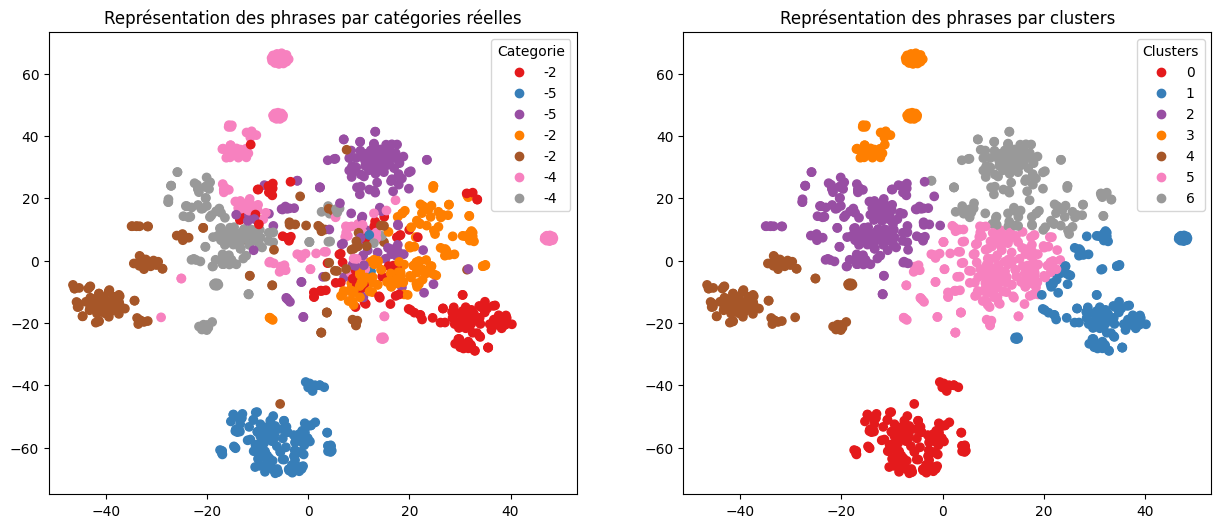

ARI :  0.3892


In [88]:
NLP.TSNE_visu_fct(X_tsne, y_cat_num, labels, y_cat_num, ARI)

In [89]:
n_top_words = 10
ctf_features_names = cvect.get_feature_names_out()
features_by_label = {}


# itérer sur les labels uniques
for label in df['cat_1'].unique():
    # sélectionner les lignes correspondant au label actuel
    mask = df['cat_1'] == label
    # extraire les features correspondant aux lignes sélectionnées
    features = X_cv[mask, :]
    # calculer la somme des TF-IDF pour chaque feature
    feature_sums = features.sum(axis=0)
    # trier les features par ordre décroissant d'importance
    feature_sort_indices = feature_sums.argsort()[::-1]
    # sélectionner les 30 premières features
    top_features = feature_sort_indices[:20]
    # extraire les noms des features sélectionnées
    top_feature_names = [ctf_features_names[i] for i in top_features]
    # stocker les features dans le dictionnaire
    features_by_label[label] = top_feature_names

dict_features = pd.DataFrame.from_dict(features_by_label)

In [90]:
dict_features

,Home Furnishing,Baby Care,Watches,Home Decor & Festive Needs,Kitchen & Dining,Beauty and Personal Care,Computers
0,"[[zyxel, hmt, hit, hinduism, hindu, hills, scrubbing, highest, se122103, herbs, hem, helps, help, sea, seal, heat, heart, healthy, health, healing, heads, head, hdmi, hd, hold, scrubber, holes, holiday, school, science, ice, i3, hz, human, huge, sciences, hp, scratch, hours, search, hour, hospital, horse, hooks, hookah, hook, hooded, hood, honour, honey, screen, screw, hot, ideapad, haveli, harness, group, grooming, grip, septic, serve, service, graphics, graphic, graph, grams, gram, services, gown, gorgeous, serving, golmaalshop, golden, gods, goddess, god, gms, glue, glow, groups, sent, gtw, guarantee, season, happy, second, handy, seeds, select, selecting, selection, handles, handle, handicrafts, hat, handicraft, semi, hamilton, send, half, ...]]","[[001, match, mat, master, massage, maroon, marketplace, marble, manufacturing, manufacturers, manufacturer, manicure, mango, manageable, man, making, makeup, majesty, maintenance, mah, magsafe, magnetic, magic, mache, macbook, mac, matte, luxury, maxima, maybe, mix, mishandling, mirror, minutes, mint, mink, minimal, milton, microwave, micro, mhz, method, metallino, message, mesleep, mesh, mental, memory, memore, meet, meenakari, medical, mechanism, means, mbps, maximum, mixfruit, lustrous, lucky, level, letter, lets, lenovo, lemongrass, led, leaving, leather, leads, leading, layers, lavender, laughs, lasting, laser, laptops, laptop, lapguard, landscape, lamps, lamp, lamination, laminated, lal, lady, levels, lunch, lid, lights, luba, lowest, loves, lots, lotions, lotion, loreal, lord, looks, looking, loofah, longevity, ...]]","[[001, nike, nights, nice, newborns, netgear, net, nehp, negative, needle, need, neckline, neck, necessary, nearest, naturals, natural, nappy, multicolour, multicoloured, multiple, multipurpose, museum, music, nkp, musical, mxofere, n150, n300, n600, na, nail, musician, multicolor, normal, notice, origional, originals, original, organic, ordinary, ordering, order, options, option, optimum, operation, operating, opening, opener, open, opaque, ones, nourishing, nutcase, nylon, obstacles, obtained, offer, notebook, offered, office, offices, offspring, oil, oils, old, offering, otg, mugs, mp3, midi, microwave, micro, mhz, mh, method, metallino, message, mesleep, mesh, mentioned, mental, memory, memore, meet, meenakari, medium, maroon, massage, master, mat, match, matte, mild, mattress, maximum, maybe, mbps, mdf, ...]]","[[001, lotion, loreal, loops, loop, loofah, london, logo, locking, lock, lively, lotions, little, lipstick, lips, lip, link, lining, liner, linen, line, lime, lifestyle, lipsticks, lots, lounge, low, maxi, mattress, match, mat, massage, manufacturers, manufacturer, manufactured, manicure, makeup, majesty, mah, magsafe, magic, machine, macbook, mac, luxury, luxurious, lunch, lukewarm, luba, lowest, lid, maxima, level, lenovo, kidz, kids, kid, keyboard, keeps, kalash, kadhai, kadai, jumpsuit, jump, kindly, juice, jrb, jersey, jazz, jasmine, jaipuri, jack, jacadi, iso, island, ios, jug, kliqvik, klub, knee, lemon, leggings, legging, leaving, leaves, leather, league, layered, layer, lavender, laughs, latest, laptops, laptop, lapguard, lace, label, la, kurta, kosher, ...]]","[[001, mink, minimum, minimal, mind, mild, midi, micro, mhz, mh, mesleep, mesh, mentioned, mishandling, mental, memory, memore, meenakari, medium, medical, mechanism, mdf, mbps, maybe, maximum, maxima, maxi, men, mattress, mixfruit, mmull, naturals, nappy, nail, n600, n300, n150, mxofere, musician, musical, museum, multicolour, mp3, mkb, movies, mountable, mount, mosaic, mood, months, month, monitor, money, moments, modem, mobiles, mobile, mouse, matte, match, mat, loreal, lord, loose, loops, loop, looking, loofah, longevity, london, logo, location, lively, lotion, little, lipstick, lips, lip, link, lining, liner, linen, lights, lifestyle, levels, level, lets, lips

### Tfidf

In [91]:
ctf = TfidfVectorizer(**params)
X_ctf = ctf.fit_transform(text)

In [92]:
print('Vocabulary size : {}'.format(len(list(ctf.vocabulary_))))
print('Stop words count : {}'.format(len(ctf.stop_words_)))

Vocabulary size : 2442
Stop words count : 3400


In [93]:
print("Tf-idf : ")
print("--------")
ARI, X_tsne, labels = NLP.ARI_fct(X_ctf, l_cat, y_cat_num)

Tf-idf : 
--------
ARI :  0.55 time :  16.0


In [94]:
df['cat_1'].unique()

array(['Home Furnishing', 'Baby Care', 'Watches',
       'Home Decor & Festive Needs', 'Kitchen & Dining',
       'Beauty and Personal Care', 'Computers'], dtype=object)

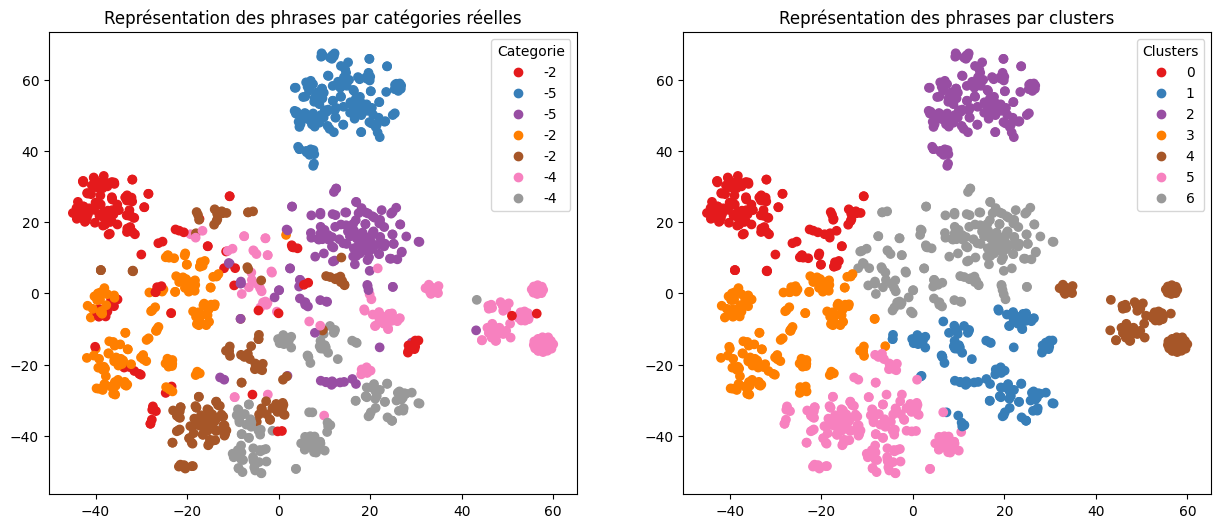

ARI :  0.55


In [95]:
NLP.TSNE_visu_fct(X_tsne, y_cat_num, labels, y_cat_num, ARI)

In [96]:
n_top_words = 10
ctf_features_names = ctf.get_feature_names_out()
features_by_label = {}


# itérer sur les labels uniques
for label in df['cat_1'].unique():
    # sélectionner les lignes correspondant au label actuel
    mask = df['cat_1'] == label
    # extraire les features correspondant aux lignes sélectionnées
    features = X_ctf[mask, :]
    # calculer la somme des TF-IDF pour chaque feature
    feature_sums = features.sum(axis=0)
    # trier les features par ordre décroissant d'importance
    feature_sort_indices = feature_sums.argsort()[::-1]
    # sélectionner les 30 premières features
    top_features = feature_sort_indices[:20]
    # extraire les noms des features sélectionnées
    top_feature_names = [ctf_features_names[i] for i in top_features]
    # stocker les features dans le dictionnaire
    features_by_label[label] = top_feature_names

dict_features = pd.DataFrame.from_dict(features_by_label)
dict_features

,Home Furnishing,Baby Care,Watches,Home Decor & Festive Needs,Kitchen & Dining,Beauty and Personal Care,Computers
0,"[[zyxel, imprint, impression, imported, important, immediately, imagination, images, showcase, illuminate, idols, idol, improper, identify, showpiece, shows, ice, i3, hz, human, huge, shrug, hp, silicon, hours, ideapad, hour, inadvertent, shoulders, install, inside, input, innovative, innovation, shock, inkjet, ink, infused, information, inflatable, inception, industrial, induction, individual, indicative, shoppingtara, shorts, independence, increase, including, includes, included, shoulder, shopmania, installation, hot, horse, healthy, health, healing, heads, head, hdmi, hd, sit, haveli, hat, harness, heart, site, sitting, handy, sj, skill, skilled, skins, handles, handle, handicrafts, handicraft, skmei, happy, hospital, heat, sipper, hooks, hookah, hook, hooded, hood, honour, honey, silicone, holiday, holes, silver, sipping, hold, hit, hinduism, ...]]","[[001, match, mat, master, massage, maroon, marketplace, marble, manufacturing, manufacturers, manufacturer, manicure, mango, manageable, man, making, makeup, majesty, maintenance, mah, magsafe, magnetic, magic, mache, macbook, mac, matte, luxury, maxima, maybe, mix, mishandling, mirror, minutes, mint, mink, minimal, milton, microwave, micro, mhz, method, metallino, message, mesleep, mesh, mental, memory, memore, meet, meenakari, medical, mechanism, means, mbps, maximum, mixfruit, lustrous, lucky, level, letter, lets, lenovo, lemongrass, led, leaving, leather, leads, leading, layers, lavender, laughs, lasting, laser, laptops, laptop, lapguard, landscape, lamps, lamp, lamination, laminated, lal, lady, levels, lunch, lid, lights, luba, lowest, loves, lots, lotions, lotion, loreal, lord, looks, looking, loofah, longevity, ...]]","[[001, nike, nights, nice, newborns, netgear, net, nehp, negative, needle, need, neckline, neck, necessary, nearest, naturals, natural, nappy, multicolour, multicoloured, multiple, multipurpose, museum, music, nkp, musical, mxofere, n150, n300, n600, na, nail, musician, multicolor, normal, notice, origional, originals, original, organic, ordinary, ordering, order, options, option, optimum, operation, operating, opening, opener, open, opaque, ones, nourishing, nutcase, nylon, obstacles, obtained, offer, notebook, offered, office, offices, offspring, oil, oils, old, offering, otg, mugs, mp3, midi, microwave, micro, mhz, mh, method, metallino, message, mesleep, mesh, mentioned, mental, memory, memore, meet, meenakari, medium, maroon, massage, master, mat, match, matte, mild, mattress, maximum, maybe, mbps, mdf, ...]]","[[001, lotion, loreal, loops, loop, loofah, london, logo, locking, lock, lively, lotions, little, lipstick, lips, lip, link, lining, liner, linen, line, lime, lifestyle, lipsticks, lots, lounge, low, maxi, mattress, match, mat, massage, manufacturers, manufacturer, manufactured, manicure, makeup, majesty, mah, magsafe, magic, machine, macbook, mac, luxury, luxurious, lunch, lukewarm, luba, lowest, lid, maxima, level, lenovo, kidz, kids, kid, keyboard, keeps, kalash, kadhai, kadai, jumpsuit, jump, kindly, juice, jrb, jersey, jazz, jasmine, jaipuri, jack, jacadi, iso, island, ios, jug, kliqvik, klub, knee, lemon, leggings, legging, leaving, leaves, leather, league, layered, layer, lavender, laughs, latest, laptops, laptop, lapguard, lace, label, la, kurta, kosher, ...]]","[[001, mink, minimum, minimal, mind, mild, midi, micro, mhz, mh, mesleep, mesh, mentioned, mishandling, mental, memory, memore, meenakari, medium, medical, mechanism, mdf, mbps, maybe, maximum, maxima, maxi, men, mattress, mixfruit, mmull, naturals, nappy, nail, n600, n300, n150, mxofere, musician, musical, museum, multicolour, mp3, mkb, movies, mountable, mount, mosaic, mood, months, month, monitor, money, moments, modem, mobiles, mobile, mouse, matte, match, mat, loreal, lord, loose, loops, loop, looking, loofah, longevity, london, logo, location, lively, lot